# Lineaire vs. kwadratische demping — crossover-snelheden

Voor elke DOF (Heave, Pitch, Roll) en elke dempingscase (S1–S4) bepalen we bij welke snelheid de **kwadratische** dempingskracht groter wordt dan de **lineaire**.

**Model**

$$F_{lin}(v) = B_{lin}\,v \qquad F_{quad}(v) = B_{quad}\,v\,|v|$$

Gelijkstelling $F_{quad} = F_{lin}$ geeft de crossover-snelheid:

$$v_{cross} = \frac{B_{lin}}{B_{quad}}$$

Boven $v_{cross}$ domineert de kwadratische term. Eenheid: m/s voor Heave, rad/s voor Pitch & Roll.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX = 'damping_scenarios.xlsx'  # pas pad aan indien nodig

## 1. Data inlezen

Het bestand heeft een dubbele header (DOF-naam op rij 1, `Category/Lin/Quad` op rij 2). We slaan beide kop-rijen over en benoemen de kolommen expliciet.

In [3]:
cols = ['Scenario', 'Description',
        'Heave_Cat', 'Heave_Lin', 'Heave_Quad',
        'Pitch_Cat', 'Pitch_Lin', 'Pitch_Quad',
        'Roll_Cat',  'Roll_Lin',  'Roll_Quad']

df = pd.read_excel(XLSX, skiprows=2, header=None, names=cols)

# coeff-kolommen numeriek maken
for dof in ['Heave', 'Pitch', 'Roll']:
    df[f'{dof}_Lin']  = pd.to_numeric(df[f'{dof}_Lin'])
    df[f'{dof}_Quad'] = pd.to_numeric(df[f'{dof}_Quad'])

df

,Scenario,Description,Heave_Cat,Heave_Lin,Heave_Quad,Pitch_Cat,Pitch_Lin,Pitch_Quad,Roll_Cat,Roll_Lin,Roll_Quad
0,S1,All Low,low,1.0,1.0,low,150,200,low,100,300.0
1,S2,All LinHigh,linhigh,6.5,1.0,linhigh,325,200,linhigh,300,300.0
2,S3,All QuadHigh,quadhigh,1.0,4.0,quadhigh,150,1300,quadhigh,100,1300.0
3,S4,All DOFbest,DOFbest,3.3,2.4,DOFbest,248,640,DOFbest,233,304.5


## 2. Crossover-snelheden berekenen

$v_{cross} = B_{lin} / B_{quad}$ voor elke combinatie van DOF en scenario.

In [4]:
DOFS  = ['Heave', 'Pitch', 'Roll']
UNITS = {'Heave': 'm/s', 'Pitch': 'rad/s', 'Roll': 'rad/s'}

cross = df[['Scenario', 'Description']].copy()

df['Description'] = df['Description'].str.replace('All', '').str.strip()

  # bijv. 'S1' of 'S2'
for dof in DOFS:
    cross[f'{dof}_vcross'] = df[f'{dof}_Lin'] / df[f'{dof}_Quad']

print('Crossover-snelheden  v = B_lin / B_quad')
print('(Heave in m/s, Pitch & Roll in rad/s)\n')
cross.round(3)

Crossover-snelheden  v = B_lin / B_quad
(Heave in m/s, Pitch & Roll in rad/s)



,Scenario,Description,Heave_vcross,Pitch_vcross,Roll_vcross
0,S1,All Low,1.000,0.750,0.333
1,S2,All LinHigh,6.500,1.625,1.000
2,S3,All QuadHigh,0.250,0.115,0.077
3,S4,All DOFbest,1.375,0.388,0.765


## 3. Subplots: 3 rijen (DOF) × 4 kolommen (dampingcases)

Per subplot tekenen we $F_{lin}(v)$ en $F_{quad}(v)$ over een snelheidsbereik dat ruim om de crossover heen ligt, plus een verticale lijn bij $v_{cross}$ en arcering waar de kwadratische kracht domineert.

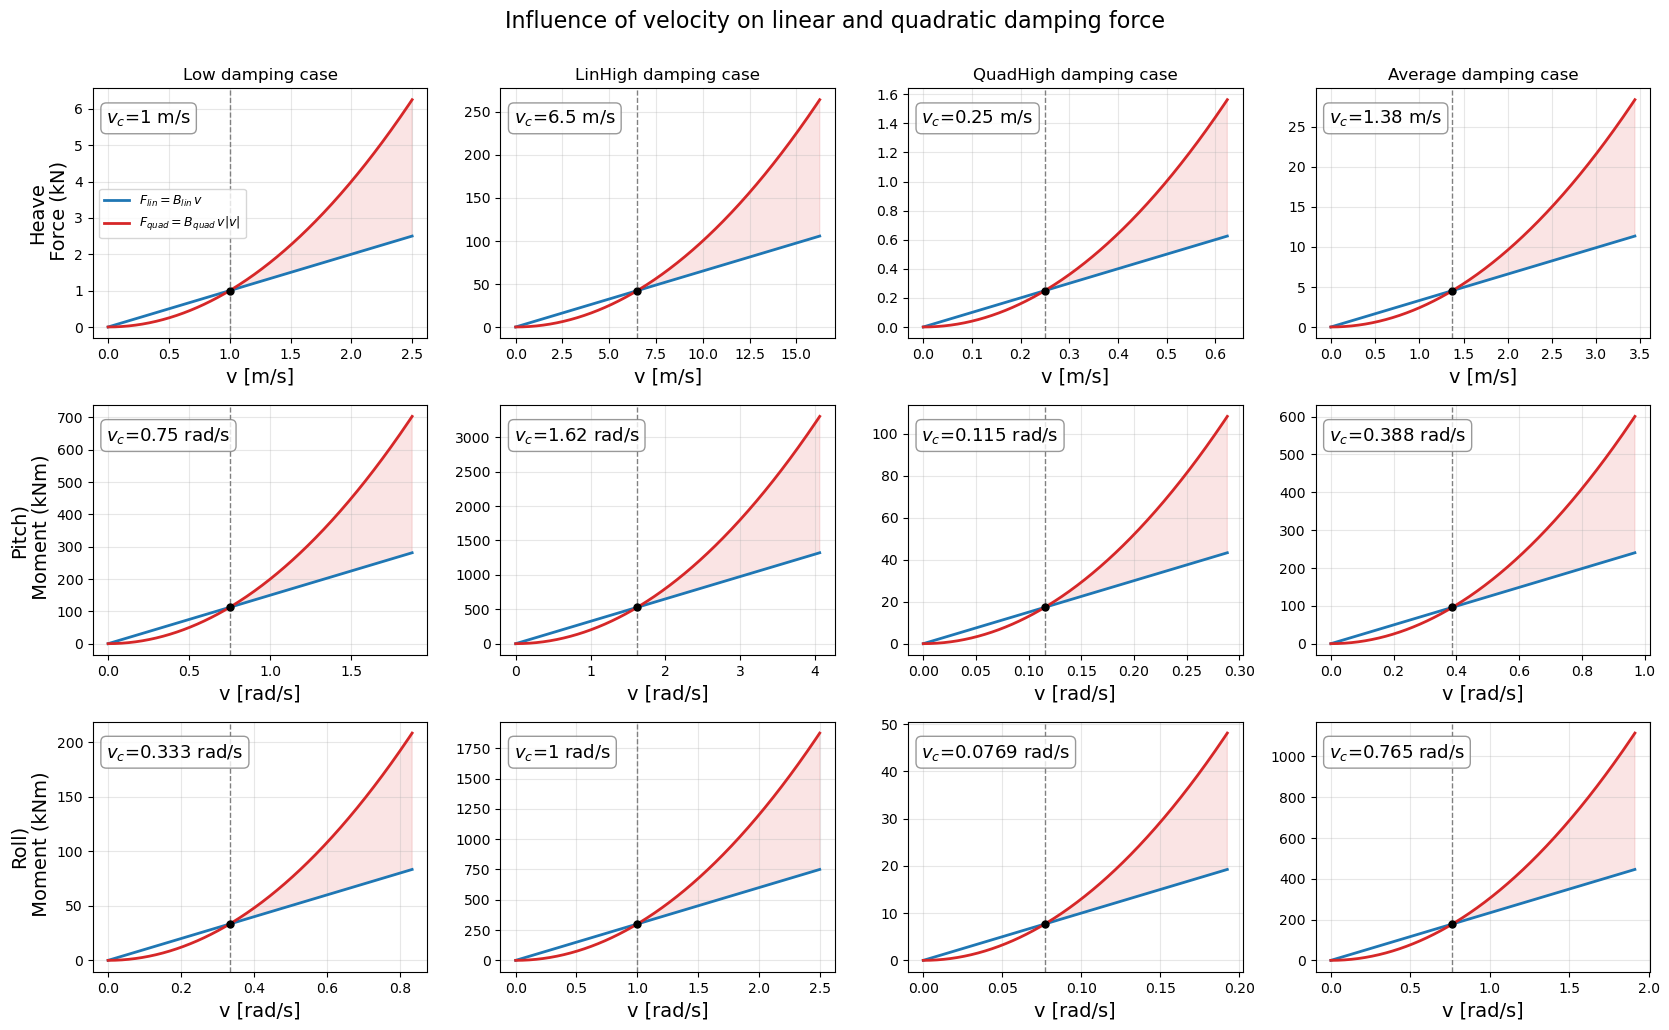

In [5]:
n_rows, n_cols = len(DOFS), len(df)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows))

C_LIN, C_QUAD = '#1f77b4', '#d62728'

for i, dof in enumerate(DOFS):
    for j, (_, row) in enumerate(df.iterrows()):
        ax = axes[i, j]
        b_lin  = row[f'{dof}_Lin']
        b_quad = row[f'{dof}_Quad']
        v_cross = b_lin / b_quad

        # snelheidsas tot 2.5x de crossover (zodat het snijpunt duidelijk zichtbaar is)
        v_max = 2.5 * v_cross if v_cross > 0 else 1.0
        v = np.linspace(0, v_max, 400)
        f_lin  = b_lin * v
        f_quad = b_quad * v * np.abs(v)

        ax.plot(v, f_lin,  color=C_LIN,  lw=2, label=r'$F_{lin}=B_{lin}\,v$')
        ax.plot(v, f_quad, color=C_QUAD, lw=2, label=r'$F_{quad}=B_{quad}\,v|v|$')

        # gebied waar kwadratisch domineert
        ax.fill_between(v, f_lin, f_quad, where=(f_quad >= f_lin),
                        color=C_QUAD, alpha=0.12)
        # crossover-lijn + markering
        f_cross = b_lin * v_cross
        ax.axvline(v_cross, color='gray', ls='--', lw=1)
        ax.plot(v_cross, f_cross, 'o', color='black', ms=5, zorder=5)

        # titel & assen
        if i == 0:
            if j ==3:
                ax.set_title(f"Average damping case", fontsize=12)

            else:
                ax.set_title(f"{row['Description']} damping case", fontsize=12)
        if j == 0:
            if dof == 'Heave':
                dof_label = 'Heave'
                dof_label += '\n  Force (kN)'  # extra regel voor kracht-eenheid
            else:
                dof_label = f'{dof})'
                dof_label += '\n  Moment (kNm)'  # extra regel voor moment-eenheid
            ax.set_ylabel(f'{dof_label} ', fontsize=14)
        ax.set_xlabel(f'v [{UNITS[dof]}]', fontsize=14)
        ax.text(0.04, 0.92, f'$v_c$={v_cross:.3g} {UNITS[dof]}',
                transform=ax.transAxes, fontsize=13, va='top',
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
        ax.grid(alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=9, loc='center left')
            

fig.suptitle('Influence of velocity on linear and quadratic damping force',
             fontsize=16, y=1.005)
fig.tight_layout()
fig.savefig('damping_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

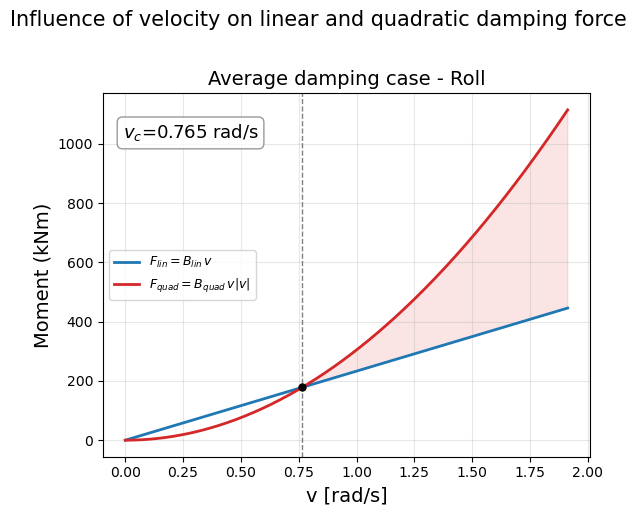

In [11]:
C_LIN, C_QUAD = '#1f77b4', '#d62728'

dof = 'Roll'
row = df.iloc[3]   # average damping case (de rij die in het grid titel 'Average' kreeg)

fig, ax = plt.subplots(figsize=(6,5))

b_lin  = row[f'{dof}_Lin']
b_quad = row[f'{dof}_Quad']
v_cross = b_lin / b_quad

# velocity axis up to 2.5x the crossover so the intersection is clearly visible
v_max = 2.5 * v_cross if v_cross > 0 else 1.0
v = np.linspace(0, v_max, 400)
f_lin  = b_lin * v
f_quad = b_quad * v * np.abs(v)

ax.plot(v, f_lin,  color=C_LIN,  lw=2, label=r'$F_{lin}=B_{lin}\,v$')
ax.plot(v, f_quad, color=C_QUAD, lw=2, label=r'$F_{quad}=B_{quad}\,v|v|$')

# region where quadratic dominates
ax.fill_between(v, f_lin, f_quad, where=(f_quad >= f_lin),
                color=C_QUAD, alpha=0.12)

# crossover line + marker
f_cross = b_lin * v_cross
ax.axvline(v_cross, color='gray', ls='--', lw=1)
ax.plot(v_cross, f_cross, 'o', color='black', ms=5, zorder=5)

ax.set_title('Average damping case - Roll', fontsize=14)
ax.set_ylabel('Moment (kNm)', fontsize=14)
ax.set_xlabel(f'v [{UNITS[dof]}]', fontsize=14)
ax.text(0.04, 0.92, f'$v_c$={v_cross:.3g} {UNITS[dof]}',
        transform=ax.transAxes, fontsize=13, va='top',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='center left')

fig.suptitle('Influence of velocity on linear and quadratic damping force',
             fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig('roll_average_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Lezen van de plot

- **Blauwe lijn** = lineaire dempingskracht (rechte lijn, helling $B_{lin}$).
- **Rode lijn** = kwadratische dempingskracht (parabool, $B_{quad}\,v|v|$).
- **Stippellijn / zwarte punt** = crossover-snelheid $v_c = B_{lin}/B_{quad}$.
- **Rood gearceerd gebied** = snelheidsbereik waar de kwadratische kracht de lineaire overtreft.

Een lage $v_c$ betekent dat de kwadratische demping al bij lage snelheid dominant wordt (bijv. de QuadHigh-case S3); een hoge $v_c$ betekent dat de lineaire demping tot hogere snelheden blijft domineren (bijv. Heave in de LinHigh-case S2).

---
## 5. Percentage van de tijd dat kwadratisch domineert

**Aanname:** de snelheid per DOF is normaal verdeeld met gemiddelde $\mu = 0$ en standaarddeviatie $\sigma$ uit de simulatiedataset.

De kans dat de kwadratische kracht groter is dan de lineaire is de kans dat $|v| > v_c$:

$$P(|v| > v_c) = 2\left(1 - \Phi\!\left(\frac{v_c}{\sigma}\right)\right)$$

waarbij $\Phi$ de standaard-normale CDF is. Dit percentage is per simulatie (rij in de grote dataset) en per dampingcase.

In [7]:
from scipy.stats import norm

# ------------------------------------------------------------------ #
# PAS HIER DE PADEN EN KOLOMNAMEN AAN                                #
# ------------------------------------------------------------------ #
CSV = 'simulation_output_redo.csv'          # pad naar je grote dataset

# kolomnamen van de snelheids-std per DOF in jouw CSV
STD_COLS = {
    'Heave': 'std velocity Z',           # m/s
    'Pitch': 'std velocity pitch',           # rad/s
    'Roll' : 'std velocity roll',            # rad/s
}
# ------------------------------------------------------------------ #

sim = pd.read_csv(CSV)

In [8]:
# Voor elke dampingcase en DOF een kolom toevoegen met het percentage
# Kolomnaam: pct_quad_dom_<DOF>_<Scenario>  (bijv. pct_quad_dom_Heave_S1)

for _, sc_row in df.iterrows():
    scenario = sc_row['Description']
    for dof in DOFS:
        v_cross = sc_row[f'{dof}_Lin'] / sc_row[f'{dof}_Quad']
        sigma   = sim[STD_COLS[dof]]
        pct     = 2 * (1 - norm.cdf(v_cross / sigma)) * 100  # in %
        sim[f'pct_{dof}_{scenario}'] = pct.round(2)

pct_cols = [c for c in sim.columns if c.startswith('pct_')]
# sim[pct_cols].describe().round(2)
sim[pct_cols].describe().round(1)

,pct_Heave_Low,pct_Pitch_Low,pct_Roll_Low,pct_Heave_LinHigh,pct_Pitch_LinHigh,pct_Roll_LinHigh,pct_Heave_QuadHigh,pct_Pitch_QuadHigh,pct_Roll_QuadHigh,pct_Heave_DOFbest,pct_Pitch_DOFbest,pct_Roll_DOFbest
count,880.0,880.0,880.0,880.0,880.0,880.0,880.0,880.0,880.0,880.0,880.0,880.0
mean,7.2,0.0,0.0,0.0,0.0,0.0,42.8,2.4,4.6,3.1,0.0,0.0
std,11.1,0.0,0.0,0.0,0.0,0.0,28.0,7.0,10.7,5.8,0.1,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,17.9,0.0,0.0,0.0,0.0,0.0
50%,0.2,0.0,0.0,0.0,0.0,0.0,44.8,0.0,0.0,0.0,0.0,0.0
75%,9.6,0.0,0.0,0.0,0.0,0.0,67.7,0.5,0.4,2.2,0.0,0.0
max,39.5,0.0,0.6,0.0,0.0,0.0,83.2,45.4,52.6,24.2,1.2,0.0


### Interpretatie

- Een waarde van bijv. **15 %** betekent: in 15 % van de tijd beweegt die DOF snel genoeg dat de kwadratische dempingskracht de lineaire overtreft.
- Een hoge $\sigma$ (grote bewegingsamplituden) geeft een hoger percentage — de staarten van de verdeling reiken verder dan $v_c$.
- Een hoge $v_c$ (bijv. S2 Heave: 6.5 m/s) geeft een laag percentage — de snelheid moet extreem hoog zijn voor kwadratisch dominant wordt.
- **Let op:** de aanname $\mu = 0$ is geldig voor golfgeïnduceerde oscillaties. Als er een systematische stroomsnelheid in de data zit, moet $\mu$ meegenomen worden.